# MATPMD4
## Assignment 1 (Stochastic Processes)
### Student ID: 3019061
### Lecturer: Anthony O’Hare (4B113)

1) Yes I have read and understood the instructions on the cover page

# Q2 Markov chain / stochastic matrix solution

We are given the transition matrix

$$
P =
\begin{pmatrix}
0.21 & 0.07 & 0.15 & 0.11 & 0.46 \\
0.00 & 1.00 & 0.00 & 0.00 & 0.00 \\
0.16 & 0.16 & 0.22 & x    & 0.26 \\
0.00 & 0.00 & 0.00 & 1.00 & 0.00 \\
0.21 & 0.27 & 0.18 & 0.24 & 0.10
\end{pmatrix}
$$

with states $A,B,C,D,E$.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Q2 (a) Find $x$

Because $P$ is a stochastic matrix, each row must sum to 1.

This must hold because each row represents the probabilities of moving from one state to all possible next states. Since the process must go somewhere after one step, the total probability in each row must be exactly 1.

Using the third row:

$$
0.16 + 0.16 + 0.22 + x + 0.26 = 1
$$

$$
0.80 + x = 1
$$

$$
x = 0.20
$$

So the missing value is

$$
{x = 0.20}
$$

n.b. Had to round x to prevent the sum being outputted as 0.19999996

In [27]:
x = 1 - (0.16 + 0.16 + 0.22 + 0.26)
print("x =", x.__round__(2))

P = np.array([
    [0.21, 0.07, 0.15, 0.11, 0.46],
    [0.00, 1.00, 0.00, 0.00, 0.00],
    [0.16, 0.16, 0.22, x,    0.26],
    [0.00, 0.00, 0.00, 1.00, 0.00],
    [0.21, 0.27, 0.18, 0.24, 0.10]
])

print("Transition matrix P:")
print(P)

x = 0.2
Transition matrix P:
[[0.21 0.07 0.15 0.11 0.46]
 [0.   1.   0.   0.   0.  ]
 [0.16 0.16 0.22 0.2  0.26]
 [0.   0.   0.   1.   0.  ]
 [0.21 0.27 0.18 0.24 0.1 ]]


The row sums are all equal to 1, confirming that $P$ is a valid stochastic matrix.

## Q2 (b) Distribution after 1, 2, and 3 generations

The initial distribution is

$$
\pi_0 = (0.13,\;0.24,\;0.32,\;0.28,\;0.03).
$$

Since this is a row vector, the update rule is

$$
\pi_{n+1} = \pi_n P.
$$

In [28]:
# Initial distribution
pi0 = np.array([0.13, 0.24, 0.32, 0.28, 0.03])

# Compute distributions after 1, 2, and 3 generations
pi1 = pi0 @ P
pi2 = pi1 @ P
pi3 = pi2 @ P

print("pi0 =", pi0)
print("pi1 =", pi1)
print("pi2 =", pi2)
print("pi3 =", pi3)

pi0 = [0.13 0.24 0.32 0.28 0.03]
pi1 = [0.0848 0.3084 0.0953 0.3655 0.146 ]
pi2 = [0.063716 0.369004 0.059966 0.428928 0.078386]
pi3 = [0.03943598 0.4042229  0.0368594  0.4667426  0.05273912]



The initial distribution is

$$
\pi_0 = (0.13,\;0.24,\;0.32,\;0.28,\;0.03)
$$

Since this is a row vector, the update rule is

$$
\pi_{n+1} = \pi_n P
$$

So we calculate:

- $\pi_1 = \pi_0 P$
- $\pi_2 = \pi_1 P$
- $\pi_3 = \pi_2 P$

### After 1 generation

$$
\pi_1 = \pi_0 P
$$

Componentwise:

$$
P(A \text{ after 1 step}) =
0.13(0.21)+0.24(0)+0.32(0.16)+0.28(0)+0.03(0.21)=0.0848
$$

$$
P(B \text{ after 1 step}) =
0.13(0.07)+0.24(1)+0.32(0.16)+0.28(0)+0.03(0.27)=0.3084
$$

$$
P(C \text{ after 1 step}) =
0.13(0.15)+0.24(0)+0.32(0.22)+0.28(0)+0.03(0.18)=0.0953
$$

$$
P(D \text{ after 1 step}) =
0.13(0.11)+0.24(0)+0.32(0.20)+0.28(1)+0.03(0.24)=0.3655
$$

$$
P(E \text{ after 1 step}) =
0.13(0.46)+0.24(0)+0.32(0.26)+0.28(0)+0.03(0.10)=0.1460
$$

Hence,

$$
\boxed{\pi_1 = (0.0848,\;0.3084,\;0.0953,\;0.3655,\;0.1460)}
$$

### After 2 generations

$$
\pi_2 = \pi_1 P
$$

This gives

$$
\boxed{\pi_2 = (0.063716,\;0.369004,\;0.059966,\;0.428928,\;0.078386)}
$$

### After 3 generations

$$
\pi_3 = \pi_2 P
$$

This gives

$$
\boxed{\pi_3 = (0.03943598,\;0.40422290,\;0.03685940,\;0.46674260,\;0.05273912)}
$$

In [30]:
states = ["A", "B", "C", "D", "E"]

df_dist = pd.DataFrame(
    [pi0, pi1, pi2, pi3],
    index=["pi0", "pi1", "pi2", "pi3"],
    columns=states
)

df_dist

,A,B,C,D,E
pi0,0.130000,0.240000,0.320000,0.280000,0.030000
pi1,0.084800,0.308400,0.095300,0.365500,0.146000
pi2,0.063716,0.369004,0.059966,0.428928,0.078386
pi3,0.039436,0.404223,0.036859,0.466743,0.052739


pi0 sum = 1.0
pi1 sum = 1.0
pi2 sum = 1.0
pi3 sum = 1.0


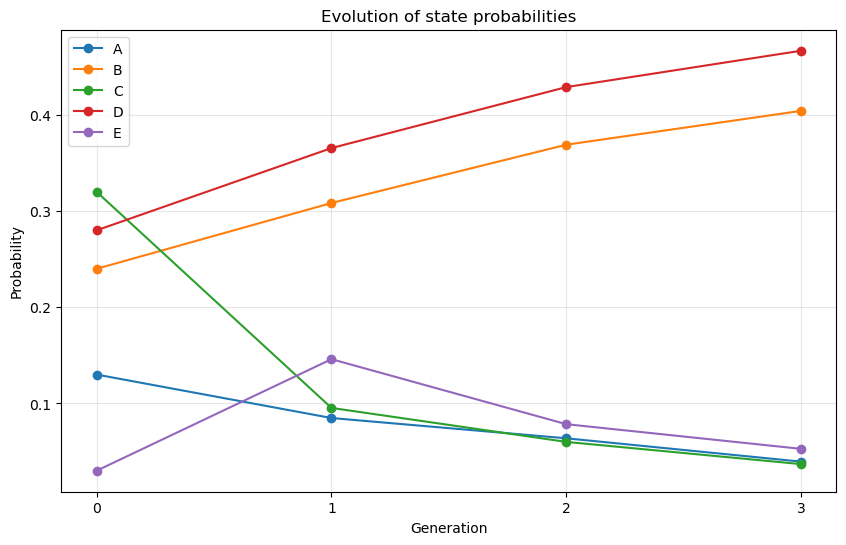

In [33]:
# Check that each distribution sums to 1
for name, vec in zip(["pi0", "pi1", "pi2", "pi3"], [pi0, pi1, pi2, pi3]):
    print(name, "sum =", vec.sum())
    

# Plot the evolution of the state probabilities
distributions = np.array([pi0, pi1, pi2, pi3])

plt.figure(figsize=(10, 6))
for i, state in enumerate(states):
    plt.plot(range(4), distributions[:, i], marker='o', label=state)

plt.xticks(range(4), ["0", "1", "2", "3"])
plt.xlabel("Generation")
plt.ylabel("Probability")
plt.title("Evolution of state probabilities")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation

The probability mass is gradually moving toward states $B$ and $D$.

This makes sense because:

- State $B$ is absorbing, since its row is $(0,1,0,0,0)$.
- State $D$ is also absorbing, since its row is $(0,0,0,1,0)$.

Once the process enters $B$ or $D$, it stays there forever.

So over time, the transient states $A,C,E$ lose probability mass, while the absorbing states $B,D$ gain probability mass.

## Q2 (c) Rewrite $P$ in canonical form

The absorbing states are $B$ and $D$, and the transient states are $A$, $C$, and $E$.

Reordering the states as

$$
(A,C,E,B,D)
$$

puts the matrix into canonical form

$$
P^* =
\begin{pmatrix}
Q & R \\
0 & I
\end{pmatrix}.
$$

In [34]:
# Canonical-form matrices
Q = np.array([
    [0.21, 0.15, 0.46],
    [0.16, 0.22, 0.26],
    [0.21, 0.18, 0.10]
])

R = np.array([
    [0.07, 0.11],
    [0.16, 0.20],
    [0.27, 0.24]
])

P_canonical = np.array([
    [0.21, 0.15, 0.46, 0.07, 0.11],
    [0.16, 0.22, 0.26, 0.16, 0.20],
    [0.21, 0.18, 0.10, 0.27, 0.24],
    [0.00, 0.00, 0.00, 1.00, 0.00],
    [0.00, 0.00, 0.00, 0.00, 1.00]
])

print("Canonical form P*:")
print(P_canonical)

Canonical form P*:
[[0.21 0.15 0.46 0.07 0.11]
 [0.16 0.22 0.26 0.16 0.2 ]
 [0.21 0.18 0.1  0.27 0.24]
 [0.   0.   0.   1.   0.  ]
 [0.   0.   0.   0.   1.  ]]


In [35]:
transient_states = ["A", "C", "E"]
absorbing_states = ["B", "D"]

display(pd.DataFrame(Q, index=transient_states, columns=transient_states))
display(pd.DataFrame(R, index=transient_states, columns=absorbing_states))

,A,C,E
A,0.21,0.15,0.46
C,0.16,0.22,0.26
E,0.21,0.18,0.10


,B,D
A,0.07,0.11
C,0.16,0.20
E,0.27,0.24


Thus,

$$
Q =
\begin{pmatrix}
0.21 & 0.15 & 0.46 \\
0.16 & 0.22 & 0.26 \\
0.21 & 0.18 & 0.10
\end{pmatrix}
$$

and

$$
R =
\begin{pmatrix}
0.07 & 0.11 \\
0.16 & 0.20 \\
0.27 & 0.24
\end{pmatrix}.
$$

## Q2 (d) Mean number of times the process is in transient state $j$, given it started in transient state $i$


The fundamental matrix is

$$
N = (I-Q)^{-1}.
$$

Each entry $N_{ij}$ gives the expected number of times the process is in transient state $j$ when it starts in transient state $i$.


In [36]:
I = np.eye(Q.shape[0])
N = np.linalg.inv(I - Q)

display(pd.DataFrame(N, index=transient_states, columns=transient_states))

,A,C,E
A,1.641192,0.545561,0.996438
C,0.497468,1.538993,0.698859
E,0.482438,0.435096,1.483385


So,

$$
N \approx
\begin{pmatrix}
1.6412 & 0.5456 & 0.9964 \\
0.4975 & 1.5390 & 0.6989 \\
0.4824 & 0.4351 & 1.4834
\end{pmatrix}.
$$

## Q2 (e) Mean number of transitions before absorption

The mean time to absorption is

$$
t = N\mathbf{1},
$$

where 1 is a column vector of ones.

In [37]:
ones = np.ones((Q.shape[0], 1))
t = N @ ones

display(pd.DataFrame(t, index=transient_states, columns=["Mean time to absorption"]))

,Mean time to absorption
A,3.183191
C,2.735320
E,2.400920


Therefore,

- starting from $A$: expected time to absorption is about $3.1832$,
- starting from $C$: expected time to absorption is about $2.7353$,
- starting from $E$: expected time to absorption is about $2.4009$.

## Q2 (f) Probability of ending in each absorbing state

The matrix of absorption probabilities is

$$
B = NR.
$$

Each entry gives the probability of eventual absorption in a particular absorbing state, given the starting transient state.

In [38]:
# Absorption probabilities
B_abs = N @ R

display(pd.DataFrame(B_abs, index=transient_states, columns=absorbing_states))

,B,D
A,0.471212,0.528788
C,0.469754,0.530246
E,0.503900,0.496100


Thus,

$$
B \approx
\begin{pmatrix}
0.4712 & 0.5288 \\
0.4698 & 0.5302 \\
0.5039 & 0.4961
\end{pmatrix}.
$$

So for example:
- if the process starts in $A$, it has probability $0.4712$ of being absorbed in $B$ and $0.5288$ of being absorbed in $D$,
- if it starts in $C$, the probabilities are $0.4698$ and $0.5302$,
- if it starts in $E$, the probabilities are $0.5039$ and $0.4961$.